# Testing of simulated bubbles

### Recreating sample size sensitivity in BSADF
We set out to recreate the sample size sensitivity found when using BSADF on Nasdaq 100 index. 
1. We use simulated time-series, where a late bubble erupts, "P_late_bubble.csv".
2. Perform the tests


In [10]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# custom imports
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


#### 1. We now display results of testing simulated late bubble from 1. jan. 1990 to 31. dec. 2025

In [11]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('../../data/simulated/timeseries/P_late_bubble.csv')
y   <- ts(dat$Price)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/fullsample_late_bubble_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv,   "results/fullsample_late_bubble_bsadf_cv.csv", row.names = FALSE)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id       adf      sadf     gsadf
  series1  2.391607  2.391607  3.759228

  gsadf_panel
     3.759228


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.39620743  1.151958  1.940131
   95  -0.03740744  1.450801  2.165954
   99   0.63280779  2.039598  2.622547



#### 2. We now display BSADF results of testing simulated late bubble from 1. jan. 1990 to 31. dec. 2025

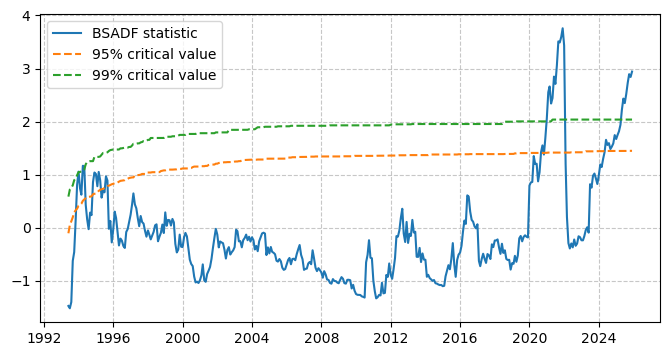

In [14]:
# load BSADF outputs
bsadf_stat = pd.read_csv("results/fullsample_late_bubble_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/fullsample_late_bubble_bsadf_cv.csv")

# load original data with dates
data = pd.read_csv(
    "../../data/simulated/timeseries/P_late_bubble.csv",
    index_col=0,
    parse_dates=True
)

# create time index
t = data.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")
plt.legend()
plt.grid(True, alpha=0.7, ls="--")
plt.savefig("plots/fullsample_late_bubble_bsadf.pdf", bbox_inches="tight")
plt.show()

#### 3. We now display results of testing simulated late bubble from 1. jan. 2015 to 31. dec. 2025

In [ ]:
%%R
library(exuber)

# 1. Load data with dates
dat <- read.csv('../../data/simulated/timeseries/P_late_bubble.csv')

# convert first column to Date
dat[,1] <- as.Date(dat[,1])

# rename for clarity (optional)
colnames(dat)[1] <- "Date"

# 2. Filter period: 2015-01-01 to 2025-12-31
dat_sub <- subset(dat, Date >= as.Date("2015-01-01") & Date <= as.Date("2025-12-31"))

# extract series
y <- ts(dat_sub$Price)
T <- length(y)

# 3. Test statistics
res <- radf(y, lag = 0)

# 4. Critical values
cv <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# 5. Save results (nyt navn!)
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/subsample_late_bubble_bsadf_stat.csv", row.names = FALSE)

bsadf_cv <- as.data.frame(cv$bsadf_cv)
write.csv(bsadf_cv, "results/subsample_late_bubble_bsadf_cv.csv", row.names = FALSE)


── radf (minw = 22, lag = 0) ───────────────────────────────────────────────────

       id       adf      sadf     gsadf
  series1  1.092563  1.875746  2.484307

  gsadf_panel
     2.484307


── Monte Carlo (minw = 22, nrep = 2000) ────────────────────────────────────────

  sig         adf      sadf     gsadf
   90  -0.4496014  1.002152  1.771418
   95  -0.1377478  1.330626  2.052327
   99   0.6666404  1.930828  2.631734



#### 4. We now display BSADF results of testing simulated late bubble from 1. jan. 2015 to 31. dec. 2025

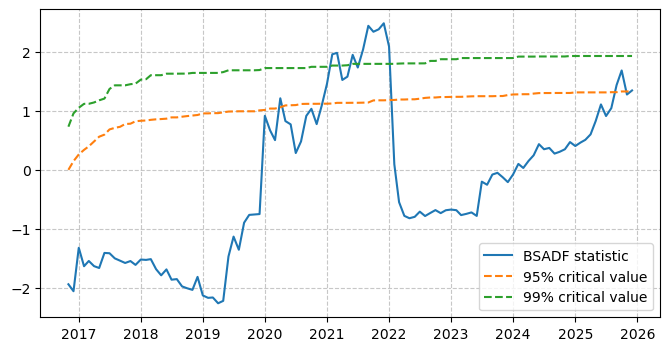

In [ ]:
# load BSADF outputs (subsample)
bsadf_stat = pd.read_csv("results/subsample_late_bubble_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/subsample_late_bubble_bsadf_cv.csv")

# load original data with dates
data = pd.read_csv(
    "../../data/simulated/timeseries/P_late_bubble.csv",
    index_col=0,
    parse_dates=True
)

# filter same period as in R
data_sub = data.loc["2015-01-01":"2025-12-31"]

# create matching time index
t = data_sub.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")

plt.legend()
plt.grid(True, alpha=0.7, ls="--")

plt.savefig("plots/subsample_late_bubble_bsadf.pdf", bbox_inches="tight")
plt.show()

#### 5. We now test the rejections rates for $H_0$ when using different seeds.
We have used seeds $[0,199]$.

The rejection frequency is computed by comparing the BSADF statistic to simulated critical values for each sample size. This ensures that the comparison accounts for the dependence of the critical values on the sample length.

In [ ]:
%%R
library(exuber)

dat <- read.csv('../../data/simulated/timeseries/P_late_bubble_multi_seeds.csv')

dat[,1] <- as.Date(dat[,1]) 
colnames(dat)[1] <- "Date"

series_names <- colnames(dat)[-1]
N <- length(series_names)

reject_full <- 0
reject_sub <- 0

# Precompute CVs (meget hurtigere!)
cv_full <- radf_mc_cv(n = 432, nrep = 2000)
cv_sub  <- radf_mc_cv(n = length(subset(dat, Date >= as.Date("2015-01-01"))[,1]), nrep = 2000)

for (name in series_names) {
  
  # ---------- FULL SAMPLE ----------
  y_full <- ts(dat[[name]])
  res_full <- radf(y_full, lag = 0)
  
  if (res_full$gsadf > cv_full$gsadf_cv[2]) {
    reject_full <- reject_full + 1
  }
  
  # ---------- SUBSAMPLE ----------
  dat_sub <- subset(dat, Date >= as.Date("2015-01-01"))
  y_sub <- ts(dat_sub[[name]])
  
  res_sub <- radf(y_sub, lag = 0)
  
  if (res_sub$gsadf > cv_sub$gsadf_cv[2]) {
    reject_sub <- reject_sub + 1
  }
}

reject_rate_full <- reject_full / N
reject_rate_sub  <- reject_sub / N

cat("Rejection rate (full sample): ", reject_rate_full, "\n")
cat("Rejection rate (subsample):  ", reject_rate_sub, "\n")


# uncomment the things below to save results in a CSV file
# results <- data.frame(
#   sample = c("Full", "Subsample"),
#   rejection_rate = c(reject_rate_full, reject_rate_sub)
# )

# write.csv(results, "results/rejection_rates.csv", row.names = FALSE)

Rejection rate (full sample):  0.795 
Rejection rate (subsample):   0.575 
